In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sys
sys.path.append("../src")

from preprocess import load_data, clean_games, engineer_features, extract_hidden_gems

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PALETTE = {"primary": "#378ADD", "accent": "#1D9E75", "muted": "#888780", "highlight": "#D4537E"}

In [2]:
data = load_data("../data/raw")
games = clean_games(data["games"])
games = engineer_features(games)
genre = data["genre_summary"]
platform = data["platform_summary"]
yearly = data["yearly_trends"]
hidden_gems = extract_hidden_gems(games)

hidden_gems.to_csv("../data/processed/hidden_gems.csv", index=False)
games.to_csv("../data/processed/games_cleaned.csv", index=False)

In [4]:
print(f"전체 타이틀 수: {len(games):,}")
print(f"장르 수: {games['genre'].nunique()}")
print(f"플랫폼 수: {games['platform'].nunique()}")
print(f"출시 연도 범위: {games['year'].min()} ~ {games['year'].max()}")
print(f"숨겨진 보석 수: {hidden_gems['is_hidden_gem'].sum() if 'is_hidden_gem' in hidden_gems.columns else len(hidden_gems)}")
print(games[["metacritic_score", "user_score", "global_sales_million", "composite_score"]].describe().round(2))

전체 타이틀 수: 50,000
장르 수: 20
플랫폼 수: 33
출시 연도 범위: 1985 ~ 2026
숨겨진 보석 수: 1486
       metacritic_score  user_score  global_sales_million  composite_score
count          50000.00    50000.00              50000.00         50000.00
mean              74.05        7.41                 26.03            74.06
std                8.63        1.16                 45.04             8.90
min               37.00        2.20                  0.05            35.20
25%               68.00        6.60                  5.14            68.10
50%               74.00        7.40                 12.80            74.10
75%               80.00        8.20                 29.29            80.10
max               99.00       10.00               1494.68            99.30


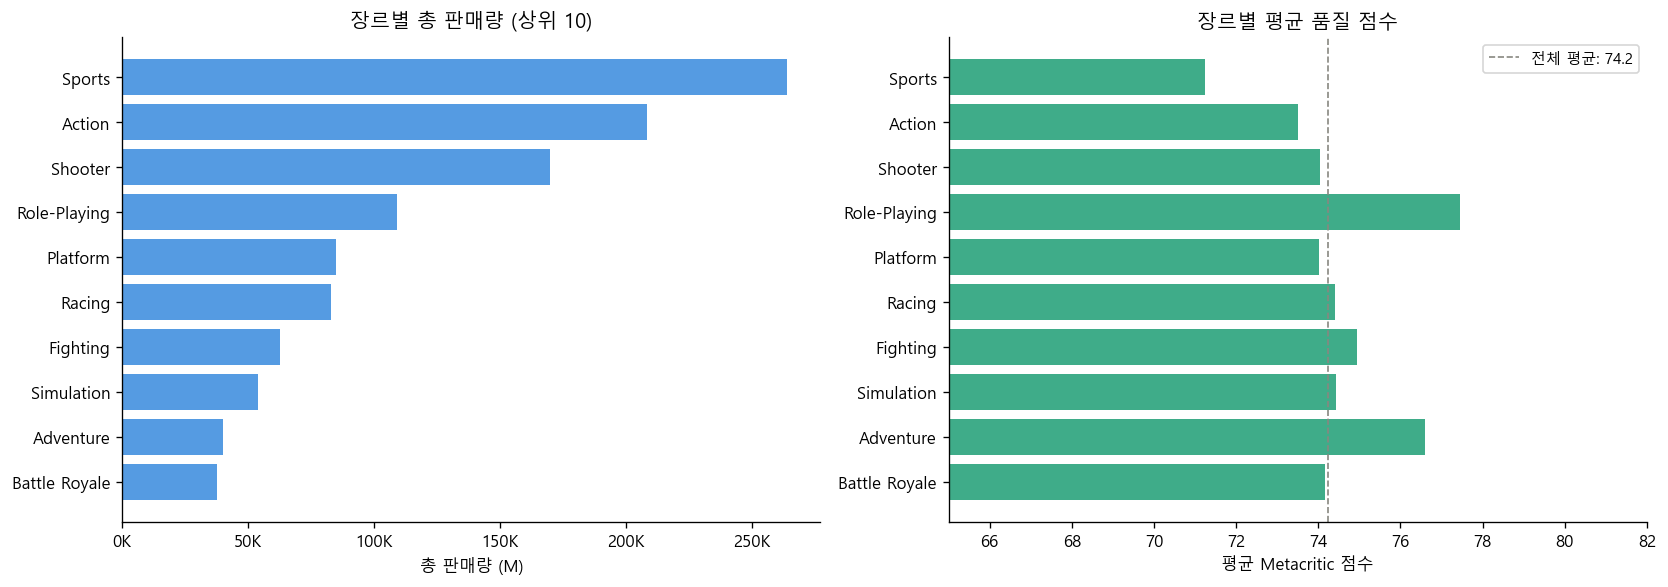

In [3]:
genre_sorted = genre.sort_values("total_sales_m", ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(genre_sorted["genre"][::-1], genre_sorted["total_sales_m"][::-1],
             color=PALETTE["primary"], alpha=0.85)
axes[0].set_xlabel("총 판매량 (M)")
axes[0].set_title("장르별 총 판매량 (상위 10)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))

axes[1].barh(genre_sorted["genre"][::-1], genre_sorted["avg_metacritic"][::-1],
             color=PALETTE["accent"], alpha=0.85)
axes[1].set_xlabel("평균 Metacritic 점수")
axes[1].set_title("장르별 평균 품질 점수")
axes[1].set_xlim(65, 82)
axes[1].axvline(genre["avg_metacritic"].mean(), color=PALETTE["muted"],
                linestyle="--", linewidth=1, label=f"전체 평균: {genre['avg_metacritic'].mean():.1f}")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/figures/genre_sales_vs_quality.png", bbox_inches="tight")
plt.show()

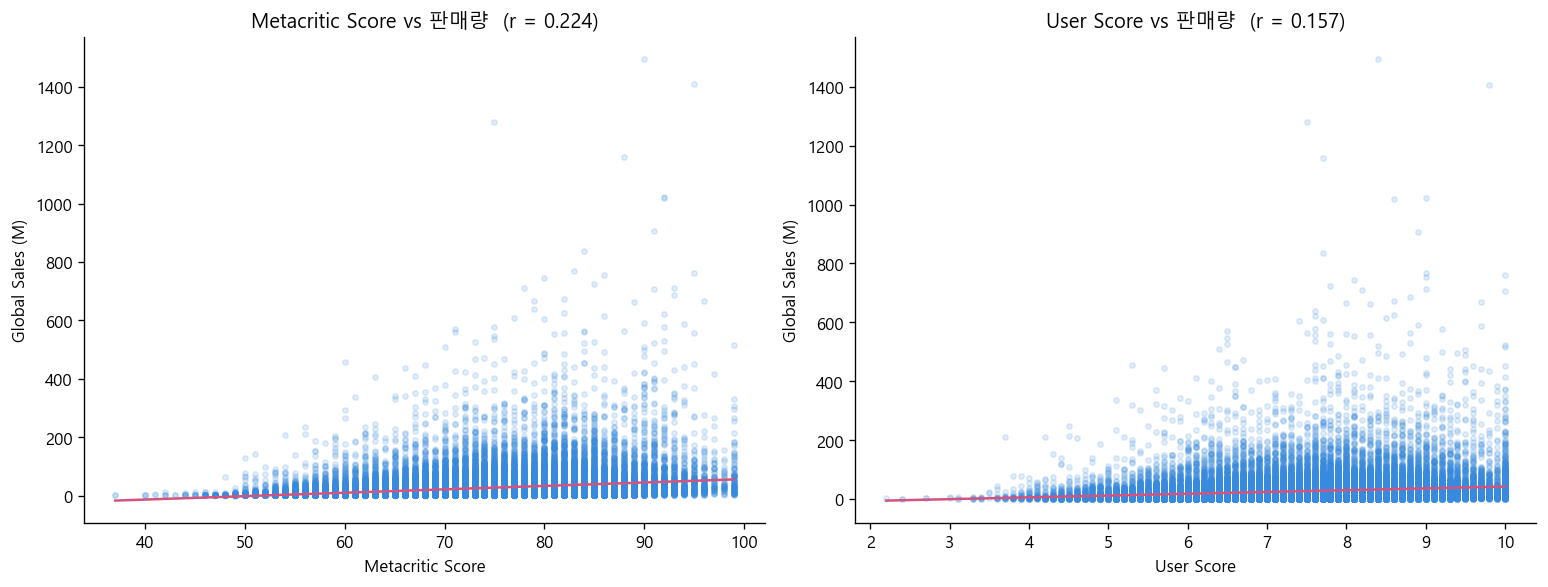

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, x_col, label in zip(axes,
                              ["metacritic_score", "user_score"],
                              ["Metacritic Score", "User Score"]):
    ax.scatter(games[x_col], games["global_sales_million"],
               alpha=0.15, s=10, color=PALETTE["primary"])

    mask = games[[x_col, "global_sales_million"]].notna().all(axis=1)
    m, b = np.polyfit(games.loc[mask, x_col], games.loc[mask, "global_sales_million"], 1)
    x_range = np.linspace(games[x_col].min(), games[x_col].max(), 100)
    ax.plot(x_range, m * x_range + b, color=PALETTE["highlight"], linewidth=1.5)

    r = games[[x_col, "global_sales_million"]].corr().iloc[0, 1]
    ax.set_title(f"{label} vs 판매량  (r = {r:.3f})")
    ax.set_xlabel(label)
    ax.set_ylabel("Global Sales (M)")

plt.tight_layout()
plt.savefig("../outputs/figures/score_sales_correlation.png", bbox_inches="tight")
plt.show()

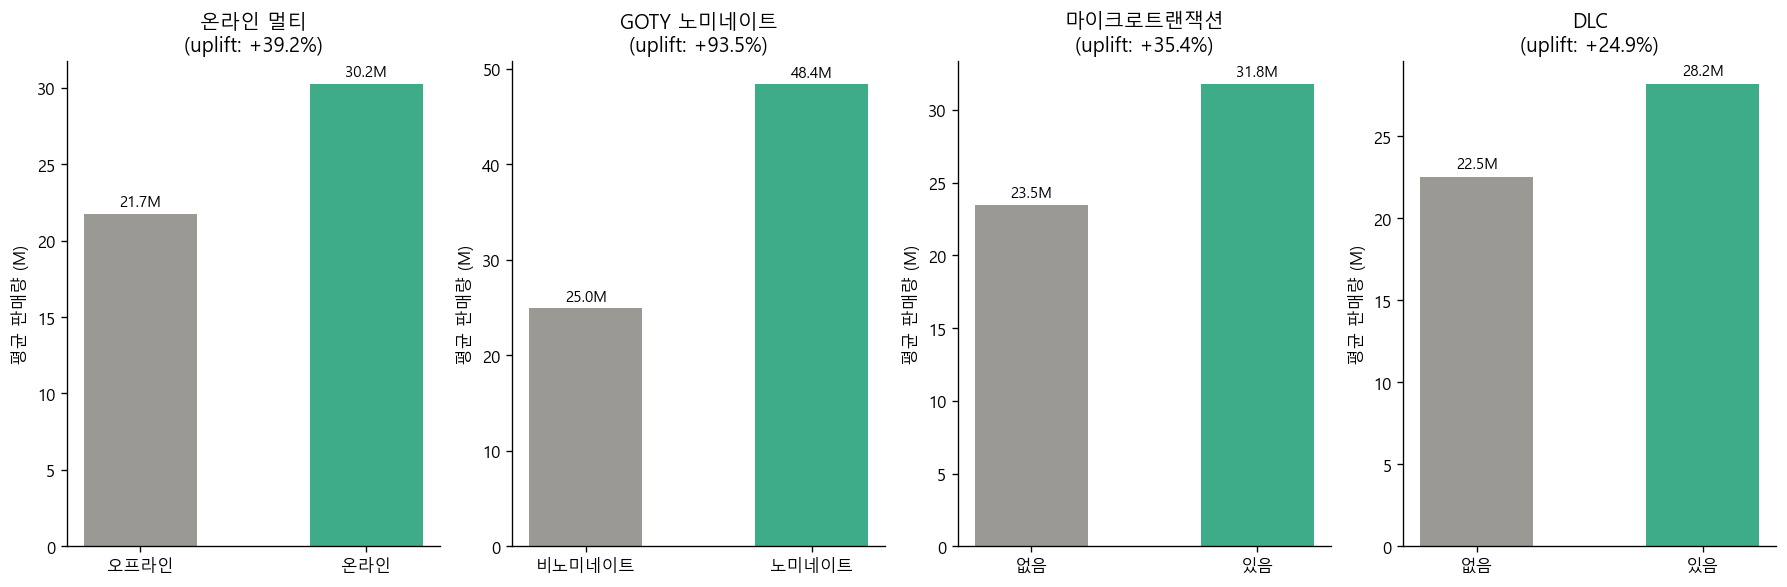

In [5]:
groups = {
    "온라인 멀티": ("online_multiplayer", ["오프라인", "온라인"]),
    "GOTY 노미네이트": ("goty_nominated", ["비노미네이트", "노미네이트"]),
    "마이크로트랜잭션": ("microtransactions", ["없음", "있음"]),
    "DLC": ("dlc_released", ["없음", "있음"]),
}

fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for ax, (feature, (col, labels)) in zip(axes, groups.items()):
    means = games.groupby(col)["global_sales_million"].mean()
    bars = ax.bar(labels, means.values,
                  color=[PALETTE["muted"], PALETTE["accent"]], alpha=0.85, width=0.5)
    lift = (means.iloc[1] / means.iloc[0] - 1) * 100
    ax.set_title(f"{feature}\n(uplift: +{lift:.1f}%)")
    ax.set_ylabel("평균 판매량 (M)")
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.3,
                f"{val:.1f}M", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/figures/feature_sales_premium.png", bbox_inches="tight")
plt.show()

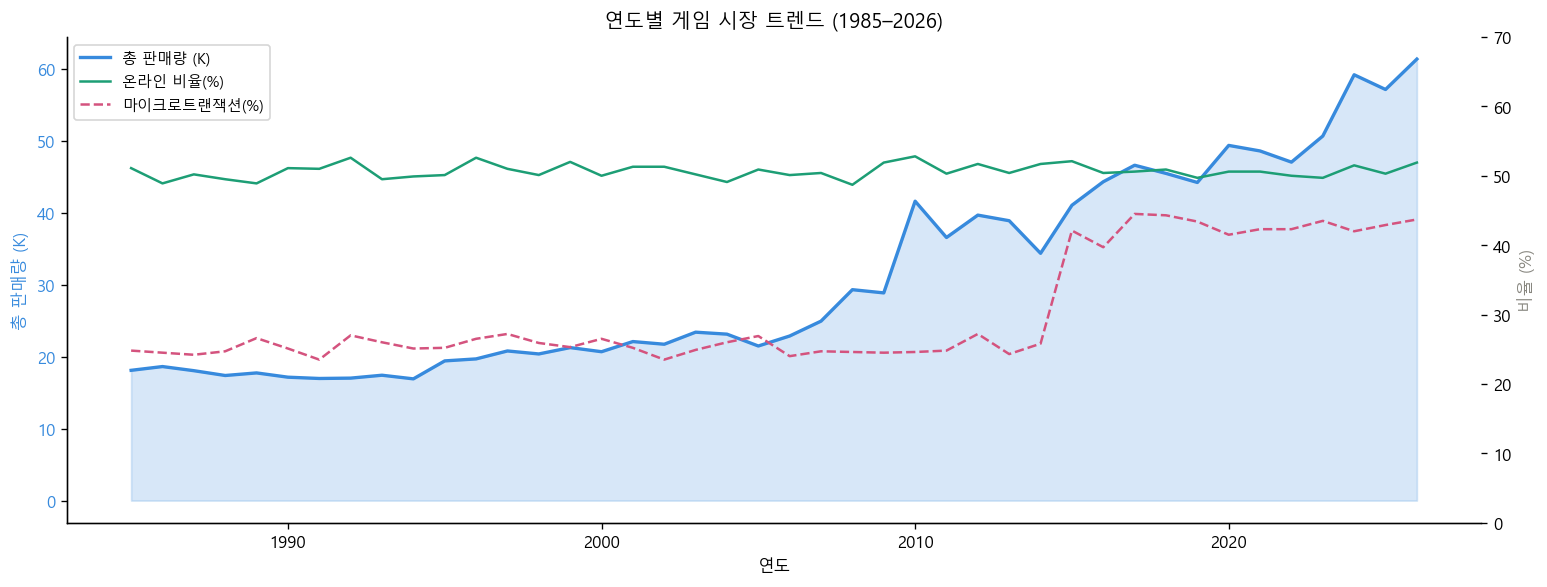

In [8]:
fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.fill_between(yearly["year"], yearly["total_sales_m"] / 1000,
                 alpha=0.2, color=PALETTE["primary"])
ax1.plot(yearly["year"], yearly["total_sales_m"] / 1000,
         color=PALETTE["primary"], linewidth=2, label="총 판매량 (K)")
ax1.set_ylabel("총 판매량 (K)", color=PALETTE["primary"])
ax1.tick_params(axis="y", labelcolor=PALETTE["primary"])

ax2 = ax1.twinx()
ax2.plot(yearly["year"], yearly["pct_online"] * 100,
         color=PALETTE["accent"], linewidth=1.5, linestyle="-", label="온라인 비율(%)")
ax2.plot(yearly["year"], yearly["pct_microtransactions"] * 100,
         color=PALETTE["highlight"], linewidth=1.5, linestyle="--", label="마이크로트랜잭션(%)")
ax2.set_ylabel("비율 (%)", color=PALETTE["muted"])
ax2.set_ylim(0, 70)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

ax1.set_title("연도별 게임 시장 트렌드 (1985–2026)")
ax1.set_xlabel("연도")

plt.tight_layout()
plt.savefig("../outputs/figures/yearly_trend.png", bbox_inches="tight")
plt.show()

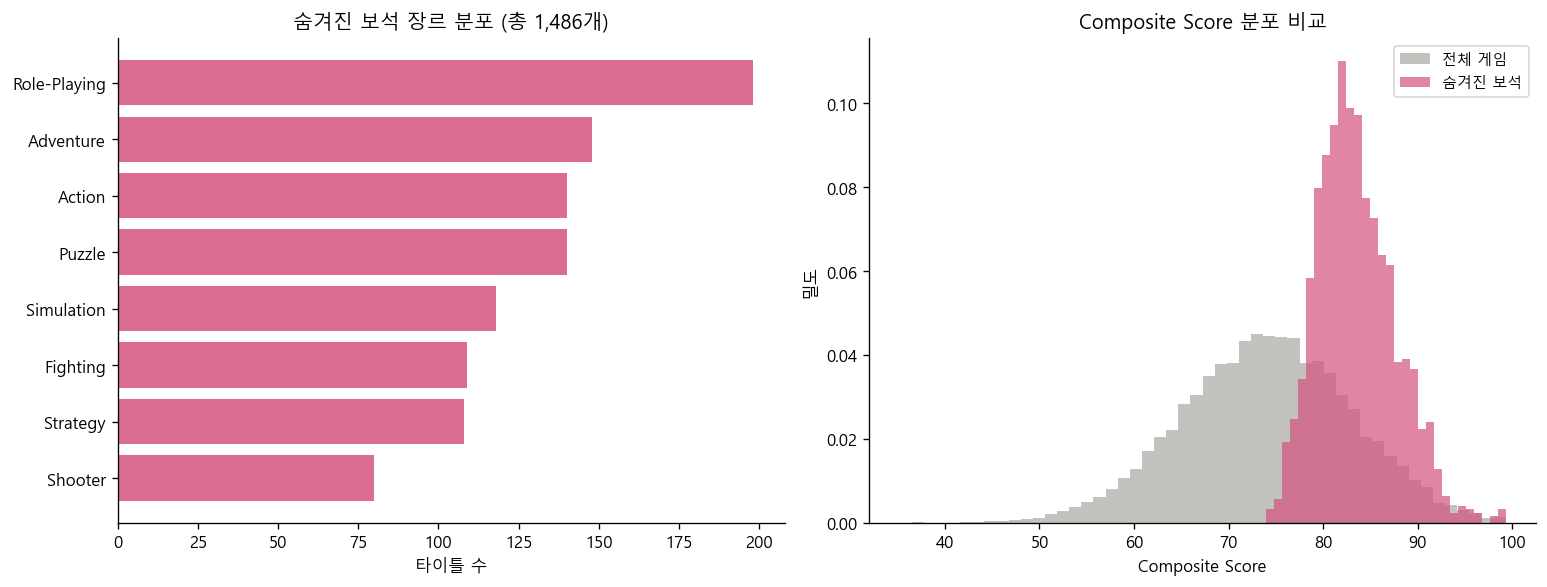

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 숨겨진 보석 장르 분포
gem_genre = hidden_gems["genre"].value_counts().head(8)
axes[0].barh(gem_genre.index[::-1], gem_genre.values[::-1],
             color=PALETTE["highlight"], alpha=0.85)
axes[0].set_title(f"숨겨진 보석 장르 분포 (총 {len(hidden_gems):,}개)")
axes[0].set_xlabel("타이틀 수")

# 전체 vs 숨겨진 보석 - composite_score 분포 비교
axes[1].hist(games["composite_score"], bins=50, alpha=0.5,
             color=PALETTE["muted"], label="전체 게임", density=True)
axes[1].hist(hidden_gems["composite_score"], bins=30, alpha=0.7,
             color=PALETTE["highlight"], label="숨겨진 보석", density=True)
axes[1].set_title("Composite Score 분포 비교")
axes[1].set_xlabel("Composite Score")
axes[1].set_ylabel("밀도")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/figures/hidden_gems_analysis.png", bbox_inches="tight")
plt.show()